# Task 4 — Pick the right chart, five times

**Data Visualization — Week 1 assignment, Task 4** · dataset: `data/mpg.csv`

398 cars sold in the US, model years 1970–1982. Five questions, and the point is that **the question chooses the
chart**:

| # | Question | The data's job | Chart |
|---|---|---|---|
| Q1 | Did cars get more fuel-efficient between 1970 and 1982? | trend | **Line** |
| Q2 | Do American, European and Japanese cars differ in fuel efficiency? | comparison | **Bar** |
| Q3 | What is the relationship between weight and fuel efficiency? | relationship | **Scatter** |
| Q4 | How is the number of cylinders distributed across the fleet? | distribution of a count | **Bar of counts (ordered)** |
| Q5 | Is the improvement in Q1 explained by Q3 — did cars get lighter? | relationship, split by era | **Scatter, two eras, with trend lines** |

Then I pick the weakest of the five and redraw it.

## 0. Setup

Same house style as the lecture notebook: the eight-hue colour-blind-safe palette, recessive grid, no chart
border, titles on the left. Every chart below inherits it, and every chart is also saved to `charts/`.

I added one small helper, `footnote()`, because several charts in this task have to **declare excluded
rows on the chart itself**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Every chart is also exported to charts/ so it can go straight into a report.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.18):
    # Small grey note under the chart - used to declare exclusions ON the chart.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


---

# Meet the data

In [2]:
cars = pd.read_csv(DATA / "mpg.csv")
print("Rows:", cars.shape[0], " Columns:", cars.shape[1])
cars.head()

Rows: 398  Columns: 9


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
missing = cars.isna().sum()
print(missing[missing > 0].to_string())
print()
print(cars.loc[cars["horsepower"].isna(), ["name", "model_year"]].to_string())

horsepower    6

                     name  model_year
32             ford pinto          71
126         ford maverick          74
330  renault lecar deluxe          80
336    ford mustang cobra          80
354           renault 18i          81
374        amc concord dl          82


**Missing data decision.** Only `horsepower` has gaps (6 cars). **None of the five questions uses horsepower**, so
I keep all 398 cars on every chart — dropping those 6 would throw away good `mpg`, `weight` and `cylinders`
values for no reason. Nothing is excluded, so no chart needs an exclusion note.

**Processing.** Turn codes into labels a reader understands: `70` becomes `1970`, `usa` becomes `USA`.

In [4]:
df = cars.copy()
df["year"] = 1900 + df["model_year"]
df["origin"] = df["origin"].map({"usa": "USA", "europe": "Europe", "japan": "Japan"})
print(df["origin"].value_counts().to_string())
df[["name", "year", "origin", "mpg", "weight", "cylinders"]].head()

origin
USA       249
Japan      79
Europe     70


,name,year,origin,mpg,weight,cylinders
0,chevrolet chevelle malibu,1970,USA,18.0,3504,8
1,buick skylark 320,1970,USA,15.0,3693,8
2,plymouth satellite,1970,USA,18.0,3436,8
3,amc rebel sst,1970,USA,16.0,3433,8
4,ford torino,1970,USA,17.0,3449,8


---

# Q1 — Did cars get more fuel-efficient between 1970 and 1982?

The small table first: one row per model year. I use the **median** mpg rather than the mean, because each year
has only 27–40 cars and a few very economical (or very thirsty) models can drag a mean around. I also keep the
25th–75th percentile range to show how much cars varied within a year.

In [5]:
by_year = df.groupby("year")["mpg"].agg(
    cars="size",
    median="median",
    p25=lambda s: s.quantile(0.25),
    p75=lambda s: s.quantile(0.75),
).round(1)
by_year

,cars,median,p25,p75
year,,,,
1970,29,16.0,14.0,22.0
1971,28,19.0,15.5,27.0
1972,28,18.5,13.8,23.0
1973,40,16.0,13.0,20.0
1974,27,24.0,16.0,27.0
1975,30,19.5,16.0,23.0
1976,34,21.0,16.8,26.4
1977,28,21.8,17.4,30.0
1978,36,20.7,19.3,28.0


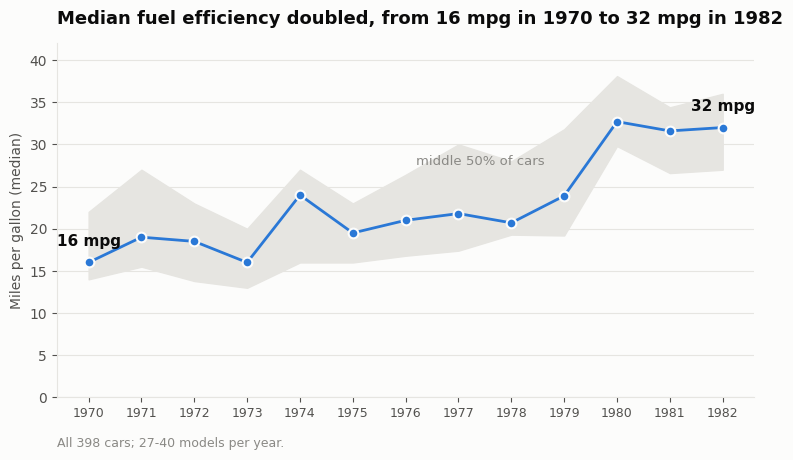

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.6))

# The middle half of cars each year - context, so it goes in a quiet band.
ax.fill_between(by_year.index, by_year["p25"], by_year["p75"], color=GRID, zorder=1)
ax.plot(by_year.index, by_year["median"], color=BLUE, marker="o", markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1.5, zorder=3)

# Label only the endpoints - they carry the message.
for yr in (1970, 1982):
    ax.annotate(f"{by_year.loc[yr, 'median']:.0f} mpg", (yr, by_year.loc[yr, "median"]),
                textcoords="offset points", xytext=(0, 12), ha="center",
                fontsize=11, fontweight="bold", color=INK)
ax.text(1976.2, by_year.loc[1976, "p75"] + 1.2, "middle 50% of cars", color=INK_MUTED, fontsize=9.5)

ax.set_title("Median fuel efficiency doubled, from 16 mpg in 1970 to 32 mpg in 1982")
ax.set_ylabel("Miles per gallon (median)")
ax.set_ylim(0, 42)
ax.set_xticks(by_year.index)
ax.tick_params(axis="x", labelsize=9)
ax.xaxis.grid(False)
footnote(ax, "All 398 cars; 27-40 models per year.", y=-0.14)

save(fig, "task4_q1_mpg_trend_line")
plt.show()

**Why a line chart:** model year is an ordered, evenly spaced axis and the question is about *change over
time*, so a line — whose slope *is* the change — fits, and I started the y-axis at 0 so "doubled" looks like
doubling.

---

# Q2 — Do American, European and Japanese cars differ in fuel efficiency?

In [7]:
by_origin = (
    df.groupby("origin")["mpg"]
    .agg(cars="size", mean="mean", median="median")
    .round(1)
    .sort_values("mean", ascending=False)
)
by_origin

,cars,mean,median
origin,,,
Japan,79,30.5,31.6
Europe,70,27.9,26.5
USA,249,20.1,18.5


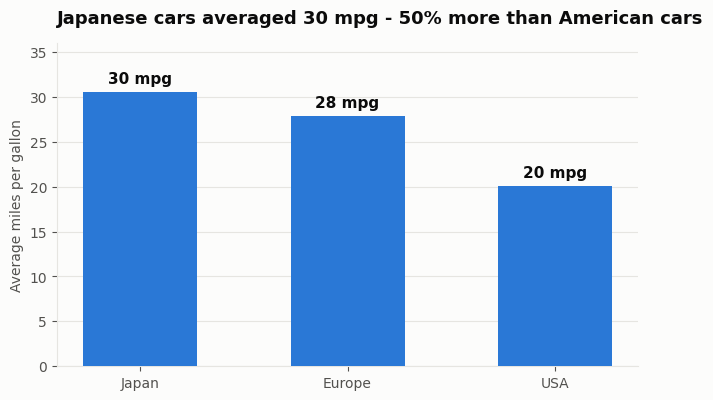

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

bars = ax.bar(by_origin.index, by_origin["mean"], color=BLUE, width=0.55, zorder=3)
for bar, value in zip(bars, by_origin["mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.6, f"{value:.0f} mpg",
            ha="center", va="bottom", fontsize=11, fontweight="bold", color=INK)

ax.set_title("Japanese cars averaged 30 mpg - 50% more than American cars")
ax.set_ylabel("Average miles per gallon")
ax.set_ylim(0, 36)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

save(fig, "task4_q2_mpg_by_origin_bar")
plt.show()

**Why a bar chart:** three separate, unordered categories compared on one number is the textbook bar chart —
sorted by value, starting at zero, one colour because the only thing that varies is the category already
named on the axis.

---

# Q3 — What is the relationship between weight and fuel efficiency?

In [9]:
r = df["weight"].corr(df["mpg"])
slope, intercept = np.polyfit(df["weight"], df["mpg"], 1)
print(f"Correlation weight vs mpg: r = {r:.2f}")
print(f"Straight-line slope: {slope * 1000:.1f} mpg per extra 1,000 lb")

Correlation weight vs mpg: r = -0.83
Straight-line slope: -7.7 mpg per extra 1,000 lb


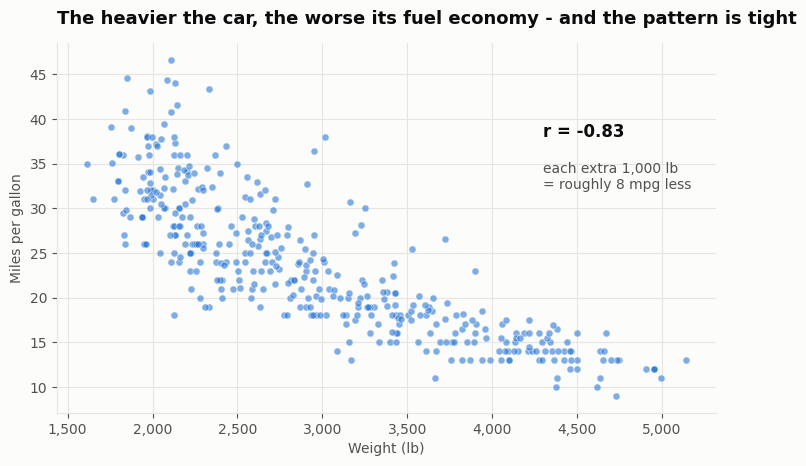

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

ax.scatter(df["weight"], df["mpg"], s=26, color=BLUE, alpha=0.6, edgecolor=SURFACE, linewidth=0.6, zorder=3)

ax.text(4300, 38, f"r = {r:.2f}", fontsize=12, fontweight="bold", color=INK)
ax.text(4300, 35.2, "each extra 1,000 lb\n= roughly 8 mpg less", fontsize=10, color=INK_SOFT, va="top")

ax.set_title("The heavier the car, the worse its fuel economy - and the pattern is tight")
ax.set_xlabel("Weight (lb)")
ax.set_ylabel("Miles per gallon")
ax.xaxis.set_major_formatter(lambda v, p: f"{v:,.0f}")
ax.set_axisbelow(True)

save(fig, "task4_q3_weight_vs_mpg_scatter")
plt.show()

**Why a scatter plot:** weight and mpg are both continuous numbers and the question is whether they move
together, which only a scatter shows point by point — and it reveals what r = −0.83 alone hides: the cloud bends
(it flattens out for the heaviest cars), so the "8 mpg per 1,000 lb" is an average over a slight curve.

---

# Q4 — How is the number of cylinders distributed across the fleet?

In [11]:
cyl = df["cylinders"].value_counts().sort_index().to_frame("cars")
cyl["percent"] = (cyl["cars"] / len(df) * 100).round(1)
cyl

,cars,percent
cylinders,,
3,4,1.0
4,204,51.3
5,3,0.8
6,84,21.1
8,103,25.9


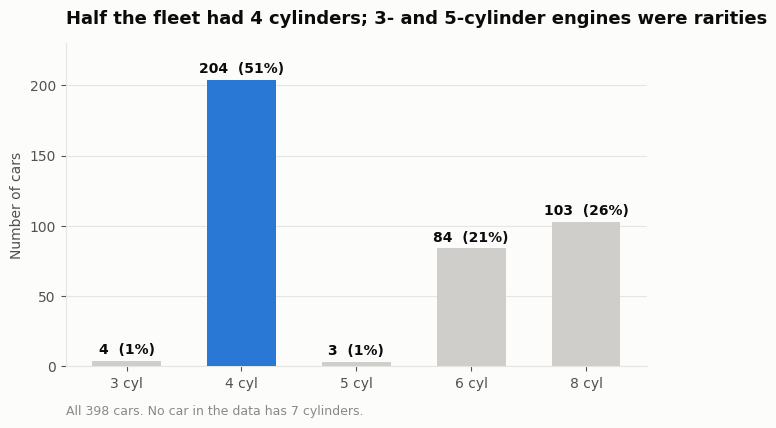

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))

labels = [f"{c} cyl" for c in cyl.index]
# Grey for context, one colour for the message: the 4-cylinder majority.
colours = [BLUE if c == 4 else QUIET for c in cyl.index]
bars = ax.bar(labels, cyl["cars"], color=colours, width=0.6, zorder=3)
for bar, n, pct in zip(bars, cyl["cars"], cyl["percent"]):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 3, f"{n}  ({pct:.0f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold", color=INK)

ax.set_title("Half the fleet had 4 cylinders; 3- and 5-cylinder engines were rarities")
ax.set_ylabel("Number of cars")
ax.set_ylim(0, 230)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
footnote(ax, "All 398 cars. No car in the data has 7 cylinders.", y=-0.15)

save(fig, "task4_q4_cylinders_bar")
plt.show()

**Why a bar chart of counts (and not a histogram or a pie):** cylinders is a small set of whole-number values,
so each value gets its own separate bar kept in its natural order (3 → 8), not binned like a continuous
histogram, and a pie with five slices — two of them about 1% — would be unreadable and an automatic deduction.

---

# Q5 — Is the improvement in Q1 explained by Q3? Did cars get lighter?

Two things have to be true for "lighter cars" to explain the gain: (1) cars actually got lighter, and (2) the
gain disappears once you compare cars **of the same weight**. The small table answers (1):

In [13]:
df["era"] = pd.cut(df["year"], bins=[1969, 1974, 1979, 1982], labels=["1970-74", "1975-79", "1980-82"])
by_era = df.groupby("era", observed=True).agg(
    cars=("mpg", "size"), avg_weight=("weight", "mean"), avg_mpg=("mpg", "mean")
).round(0)
by_era

,cars,avg_weight,avg_mpg
era,,,
1970-74,152,3203.0,19.0
1975-79,157,3029.0,23.0
1980-82,89,2471.0,32.0


In [14]:
# How much of the 1970 -> 1982 gain does the weight change account for?
# Fit mpg on weight AND year together, then ask: how many mpg does the weight drop alone buy?
X = np.column_stack([np.ones(len(df)), df["weight"], df["year"]])
b0, b_weight, b_year = np.linalg.lstsq(X, df["mpg"], rcond=None)[0]

d_weight = df.loc[df.year == 1982, "weight"].mean() - df.loc[df.year == 1970, "weight"].mean()
d_mpg = df.loc[df.year == 1982, "mpg"].mean() - df.loc[df.year == 1970, "mpg"].mean()
from_weight = b_weight * d_weight

print(f"Average weight change 1970 -> 1982: {d_weight:+,.0f} lb")
print(f"Average mpg change    1970 -> 1982: {d_mpg:+.1f} mpg")
print(f"Explained by weight alone:          {from_weight:+.1f} mpg  ({from_weight / d_mpg:.0%})")
print(f"Gain per model year at FIXED weight: {b_year:+.2f} mpg/year")

early, late = df[df["era"] == "1970-74"], df[df["era"] == "1980-82"]
fit_early = np.polyfit(early["weight"], early["mpg"], 1)
fit_late = np.polyfit(late["weight"], late["mpg"], 1)
gap_2500 = np.polyval(fit_late, 2500) - np.polyval(fit_early, 2500)
print(f"At 2,500 lb, a 1980-82 car gets {gap_2500:.1f} mpg more than a 1970-74 car")

Average weight change 1970 -> 1982: -919 lb
Average mpg change    1970 -> 1982: +14.0 mpg
Explained by weight alone:          +6.1 mpg  (44%)
Gain per model year at FIXED weight: +0.76 mpg/year
At 2,500 lb, a 1980-82 car gets 8.4 mpg more than a 1970-74 car


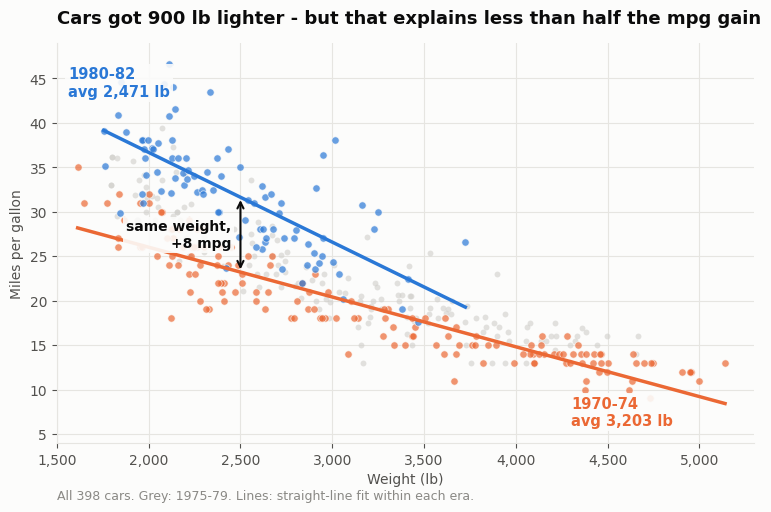

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.2))

# Context: the middle years, in grey.
mid = df[df["era"] == "1975-79"]
ax.scatter(mid["weight"], mid["mpg"], s=18, color=QUIET, alpha=0.6, linewidth=0, zorder=2)

# Message: the first and last eras, each with its own trend line.
for data, fit, colour, label, lx, ly in [
    (early, fit_early, ORANGE, "1970-74", 4300, 7.5),
    (late, fit_late, BLUE, "1980-82", 1560, 44.5),
]:
    ax.scatter(data["weight"], data["mpg"], s=28, color=colour, alpha=0.7,
               edgecolor=SURFACE, linewidth=0.6, zorder=3)
    xs = np.array([data["weight"].min(), data["weight"].max()])
    ax.plot(xs, np.polyval(fit, xs), color=colour, linewidth=2.5, zorder=4)
    ax.text(lx, ly, f"{label}\navg {data['weight'].mean():,.0f} lb", color=colour,
            fontsize=10.5, fontweight="bold", va="center", zorder=6,
            bbox={"facecolor": SURFACE, "edgecolor": "none", "alpha": 0.9, "pad": 2})

# The key reading: vertical gap at the same weight.
y0, y1 = np.polyval(fit_early, 2500), np.polyval(fit_late, 2500)
ax.annotate("", xy=(2500, y1), xytext=(2500, y0),
            arrowprops={"arrowstyle": "<->", "color": INK, "linewidth": 1.5}, zorder=5)
ax.text(2450, (y0 + y1) / 2, f"same weight,\n+{y1 - y0:.0f} mpg", fontsize=10,
        fontweight="bold", color=INK, va="center", ha="right", zorder=6,
        bbox={"facecolor": SURFACE, "edgecolor": "none", "alpha": 0.9, "pad": 2})

ax.set_title("Cars got 900 lb lighter - but that explains less than half the mpg gain")
ax.set_xlabel("Weight (lb)")
ax.set_ylabel("Miles per gallon")
ax.set_xlim(1500, 5300)
ax.set_ylim(4, 49)
ax.xaxis.set_major_formatter(lambda v, p: f"{v:,.0f}")
ax.set_axisbelow(True)
footnote(ax, "All 398 cars. Grey: 1975-79. Lines: straight-line fit within each era.", y=-0.14)

save(fig, "task4_q5_weight_explains_gain")
plt.show()

**Why this chart:** the question is whether one relationship (weight → mpg) explains a change over time, so I
reused Q3's scatter and split it by era — the orange cloud sitting to the right of the blue one shows cars got
lighter, and the blue line sitting *above* the orange one shows that even at the same weight newer cars went
further, which a line chart of averages could never separate.

**Answer:** partly. Cars did get lighter — about 900 lb on average between 1970 and 1982 — and weight alone
accounts for about **6 of the 14 mpg** gained (≈ 44%). The rest happened *at the same weight*: a 2,500 lb car
from 1980–82 gets about 8 mpg more than a 2,500 lb car from 1970–74. That is technology and engine mix — smaller
engines, more 4-cylinder cars, fuel injection — driven by the 1970s oil crises and US fuel-economy rules from
1978 onwards.

---

# The weakest chart — and the redraw

**My weakest chart is Q2** (the bar of average mpg by origin). It follows the rules — sorted, zero baseline,
labelled, finding in the title — but it is still misleading, for two reasons:

1. **A bar of averages hides the spread.** It shows three numbers and invites the reader to think "every
   Japanese car beats every American car". The bars tell you nothing about how much the three groups overlap.
2. **It hides a confounder.** American manufacturers sold almost all of the 6- and 8-cylinder cars; Europe and
   Japan sold almost none. So the bar partly compares *engine sizes*, not *countries*.

In [16]:
print("Cars by origin and number of cylinders:")
print(pd.crosstab(df["origin"], df["cylinders"]).to_string())
print()
print("Median mpg, 4-cylinder cars only:")
print(df[df["cylinders"] == 4].groupby("origin")["mpg"].median().to_string())

Cars by origin and number of cylinders:
cylinders  3   4  5   6    8
origin                      
Europe     0  63  3   4    0
Japan      4  69  0   6    0
USA        0  72  0  74  103

Median mpg, 4-cylinder cars only:
origin
Europe    27.0
Japan     32.0
USA       27.0


That second table is striking: comparing **4-cylinder cars only**, American and European cars have the *same*
median (27 mpg). Most of the USA's gap in Q2 came from its big engines.

**The redraw:** every car as a dot, so the spread and overlap are visible. Each origin gets two rows — all
cars, and 4-cylinder cars only — with the median marked as a bold line and labelled. Colour now means one
thing: **blue = 4-cylinder cars**; grey = everything else.

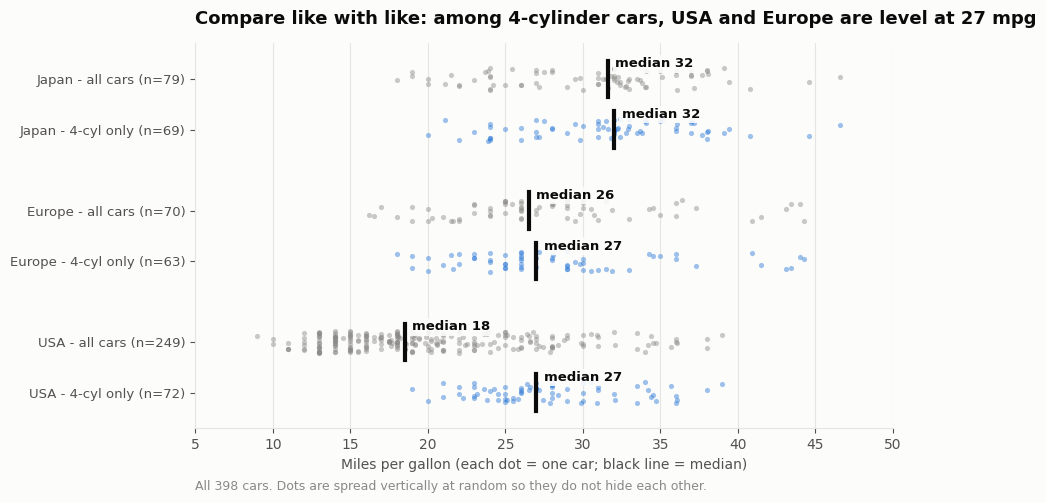

In [17]:
rng = np.random.default_rng(7)  # fixed seed so the jitter is reproducible
origins = ["Japan", "Europe", "USA"]

fig, ax = plt.subplots(figsize=(9, 5))

rows = []
for i, origin in enumerate(origins):
    rows.append((origin, "all cars", df[df["origin"] == origin]))
    rows.append((origin, "4-cyl only", df[(df["origin"] == origin) & (df["cylinders"] == 4)]))

ytick_pos, ytick_lab = [], []
for j, (origin, subset, data) in enumerate(rows):
    y = -(j + (j // 2) * 0.6)  # small gap between origin groups
    colour = BLUE if subset == "4-cyl only" else INK_MUTED
    jitter = rng.uniform(-0.22, 0.22, len(data))
    ax.scatter(data["mpg"], y + jitter, s=14, color=colour, alpha=0.45, linewidth=0, zorder=3)
    med = data["mpg"].median()
    ax.plot([med, med], [y - 0.36, y + 0.36], color=INK, linewidth=3, zorder=4)
    ax.text(med + 0.5, y + 0.30, f"median {med:.0f}", ha="left", va="center", fontsize=9.5,
            fontweight="bold", color=INK, zorder=6,
            bbox={"facecolor": SURFACE, "edgecolor": "none", "alpha": 0.9, "pad": 1.5})
    ytick_pos.append(y)
    ytick_lab.append(f"{origin} - {subset} (n={len(data)})")

ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_lab, fontsize=9.5)
ax.yaxis.grid(False)
ax.set_xlim(5, 50)
ax.set_xlabel("Miles per gallon (each dot = one car; black line = median)")
ax.set_title("Compare like with like: among 4-cylinder cars, USA and Europe are level at 27 mpg")
ax.set_axisbelow(True)
footnote(ax, "All 398 cars. Dots are spread vertically at random so they do not hide each other.", y=-0.16)

save(fig, "task4_q2_redraw_mpg_by_origin")
plt.show()

### What I changed, and why

| Before (Q2 bar) | After (redraw) | Why |
|---|---|---|
| 3 averages | Every car as a dot, plus the median | Shows spread and overlap — plenty of American cars beat plenty of Japanese ones |
| Mean | Median | Less pulled around by a few extreme cars |
| Countries only | Countries × "all cars / 4-cylinder only" | Separates the effect of origin from the effect of engine size |
| One colour, no meaning | Blue = 4-cylinder, grey = rest | Colour now carries the comparison that matters |
| "Japanese cars beat American cars by 50%" | "Among 4-cylinder cars, USA and Europe are level" | A more honest finding — Japan still leads, but the American gap was mostly engine size |

Why a **strip (dot) plot** and not bars: bars encode a single number by length, so they can only ever show the
average. When the question is "do these groups *differ*", the reader needs to see the distributions, not just
their centres. There are no bars here, so no zero baseline is needed — position along a common scale is the
encoding.